## Analyse prédictive de l’attrition RH

## ⚙️ Régression logistique, Random Forest et analyse de survie

### 1-Dataset et librairies nécessaires

In [5]:
import pandas as pd

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

data = pd.read_csv("Data/WA_Fn-UseC_-HR-Employee-Attrition_S14.csv")
data.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


### 2-Préparation des données

In [15]:
data_clean = data.copy()

for col in data_clean.select_dtypes(include="object"):
    data_clean[col] = LabelEncoder().fit_transform(data_clean[col])

### 3-Régression logistique

In [7]:
X = data_clean.drop("Attrition", axis=1)
y = data_clean["Attrition"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.99      0.93       255
           1       0.67      0.15      0.25        39

    accuracy                           0.88       294
   macro avg       0.78      0.57      0.59       294
weighted avg       0.86      0.88      0.84       294



c:\Users\hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### 4-Random Forest

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf = RandomForestClassifier(n_estimators=300, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred_rf))

importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).head(10)

Accuracy: 0.8741496598639455


MonthlyIncome        0.076096
OverTime             0.062600
Age                  0.056604
DailyRate            0.051169
EmployeeNumber       0.048578
TotalWorkingYears    0.047699
MonthlyRate          0.047064
HourlyRate           0.043456
DistanceFromHome     0.042946
YearsAtCompany       0.041937
dtype: float64

### 5-Analyse de survie

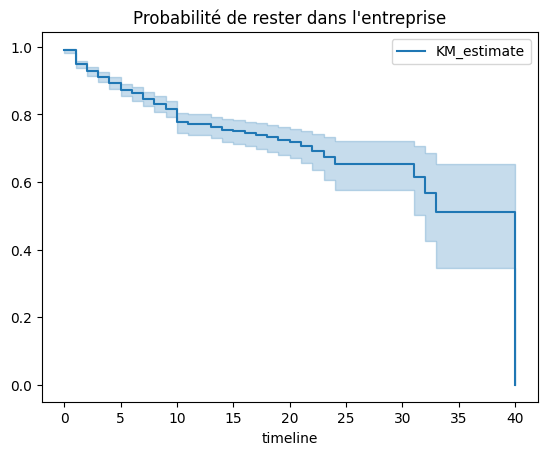

In [16]:
import matplotlib.pyplot as plt

from lifelines import KaplanMeierFitter

kmf = KaplanMeierFitter()

T = data_clean["YearsAtCompany"]
E = data_clean["Attrition"]

kmf.fit(T, event_observed=E)

kmf.plot_survival_function()
plt.title("Probabilité de rester dans l'entreprise")
plt.show()

### 6-Résumé

L’analyse croisée des modèles et des courbes de survie met en évidence une dynamique d’attrition complexe, où les facteurs individuels et organisationnels jouent un rôle complémentaire.
Un modèle précis mais peu sensible aux départs. La régression logistique atteint une accuracy de 88 %, mais cette performance masque une limite importante :

elle identifie très bien les collaborateurs qui restent (recall = 0.99)

mais détecte très peu ceux qui quittent (recall = 0.15)

Autrement dit, le modèle est fiable pour prédire la stabilité, mais peu efficace pour anticiper les départs (“Yes” minoritaires).
La random forest confirme cette tendance avec une accuracy de 87 %, mais apporte une information clé : les variables les plus importantes dans la prédiction de l’attrition sont :

MonthlyIncome, OverTime, Age, DailyRate, EmployeeNumber, TotalWorkingYears, MonthlyRate, HourlyRate, DistanceFromHome et YearsAtCompany.

Ces résultats montrent que l’attrition est fortement liée à des facteurs financiers, organisationnels (heures supplémentaires), et expérientiels (ancienneté, distance domicile‑travail).
La courbe de Kaplan‑Meier quant à elle, apporte une lecture complémentaire :

la probabilité de rester dans l’entreprise démarre à 1.0

elle diminue progressivement jusqu’à 0.5 entre 0 et 25 ans

se stabilise un temps

puis chute à 0.3 entre 30 et 35 ans

avant une dernière baisse vers 0.1 autour de 40 ans

NB : année = ancienneté

Conclusion : l’attrition n’est pas un phénomène aléatoire, mais le résultat d’un ensemble de facteurs liés à la rémunération, la charge de travail, l’ancienneté et le parcours professionnel.
Les modèles prédictifs permettent d’identifier les profils à risque, tandis que l’analyse de survie met en lumière les moments où ces risques deviennent les plus élevés.